# Analyse: Menschliche Bewertung vs. LLM-Bewertung

### Teil 1: Basis Analyse
Hier arbeite ich mit der Datei `alle_human_und_llm_relabel.csv`. Das ist der Master-Datensatz mit allen 92 Dokumenten. In diesem Teil geht es immer um den **gesamten** Datensatz, noch ohne Filter auf einzelne Untergruppen.

### 1.1 Daten einlesen

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Farben, Schriftgröße usw.
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

# Die Haupt-CSV mit allen Dokumenten einlesen
# sep=';' weil die Datei mit Semikolon statt Komma getrennt ist
df = pd.read_csv('alle_human_und_llm_relabel.csv', sep=';')

# Manchmal haben Spaltennamen unsichtbare Leerzeichen am Anfang/Ende -> die entfernen wir hier
df.columns = df.columns.str.strip()

print(f"Erfolgreich {len(df)} Dokumente für die Analyse geladen!")


Erfolgreich 92 Dokumente für die Analyse geladen!


### 1.2 Hatten die Dokumente schon eine englische Teilübersetzung?

Absolute Zahlen:
has english partial (yes / no)
yes    57
no     35
Name: count, dtype: int64


C:\Users\marya\AppData\Local\Temp\ipykernel_11016\2631619799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=translation_counts.index, y=translation_counts.values, palette="Blues_r")


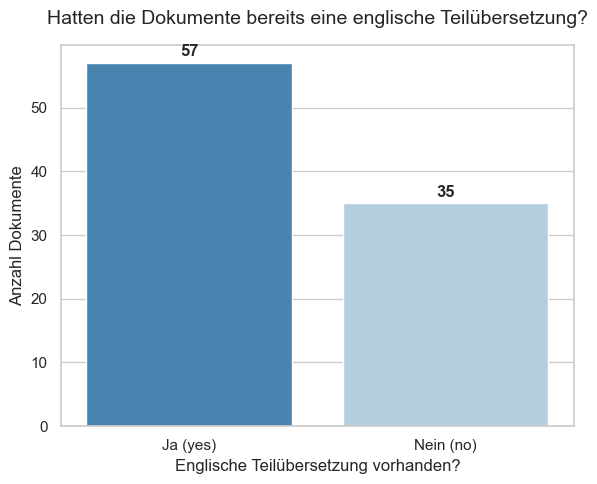

In [2]:
# Wir zählen wie oft "yes" und "no" in der Spalte vorkommen
translation_counts = df['has english partial (yes / no)'].str.strip().str.lower().value_counts()
print("Absolute Zahlen:")
print(df['has english partial (yes / no)'].value_counts())

# Balkendiagramm dazu
plt.figure(figsize=(6, 5))
ax = sns.barplot(x=translation_counts.index, y=translation_counts.values, palette="Blues_r")

plt.title("Hatten die Dokumente bereits eine englische Teilübersetzung?", fontsize=14, pad=15)
plt.xlabel("Englische Teilübersetzung vorhanden?")
plt.ylabel("Anzahl Dokumente")
plt.xticks([0, 1], ['Ja (yes)', 'Nein (no)'])

# Die genaue Anzahl direkt über jeden Balken schreiben, damit man es nicht abschätzen muss
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_1_teiluebersetzung.png', dpi=300)
plt.show()


### 1.3 Wo im Dokument stand die englische Übersetzung?

Oben (`top`) oder unten (`bottom`)? Dokumente ohne Angabe (`n.a.`) lassen wir hier weg.

Position der Übersetzung (ohne n.a.):
English where (top - bottom)
bottom    35
top       22
Name: count, dtype: int64


C:\Users\marya\AppData\Local\Temp\ipykernel_11016\4020889353.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=position_counts.index, y=position_counts.values, palette="Purples_r")


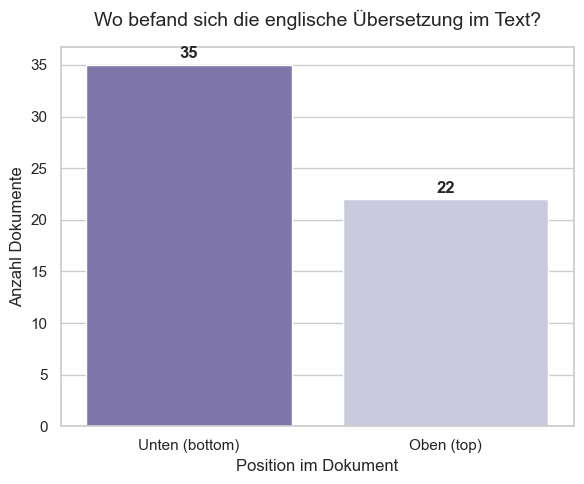

In [3]:
# n.a. rausfiltern, weil uns nur die Dokumente mit einer klaren Position interessieren
df_with_translation = df[df['English where (top - bottom)'].str.strip().str.lower() != 'n.a']
position_counts = df_with_translation['English where (top - bottom)'].str.strip().str.lower().value_counts()

print("Position der Übersetzung (ohne n.a.):")
print(position_counts)

plt.figure(figsize=(6, 5))
ax = sns.barplot(x=position_counts.index, y=position_counts.values, palette="Purples_r")

plt.title("Wo befand sich die englische Übersetzung im Text?", fontsize=14, pad=15)
plt.xlabel("Position im Dokument")
plt.ylabel("Anzahl Dokumente")
plt.xticks([0, 1], ['Unten (bottom)', 'Oben (top)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_2_position.png', dpi=300)
plt.show()


### 1.4 Team vs. LLM – Vergleich über alle Dokumente

Hier vergleichen wir zum ersten Mal direkt, wie unser Team und das LLM die Dokumente bewertet haben (alle 92, noch ohne jeden Filter).

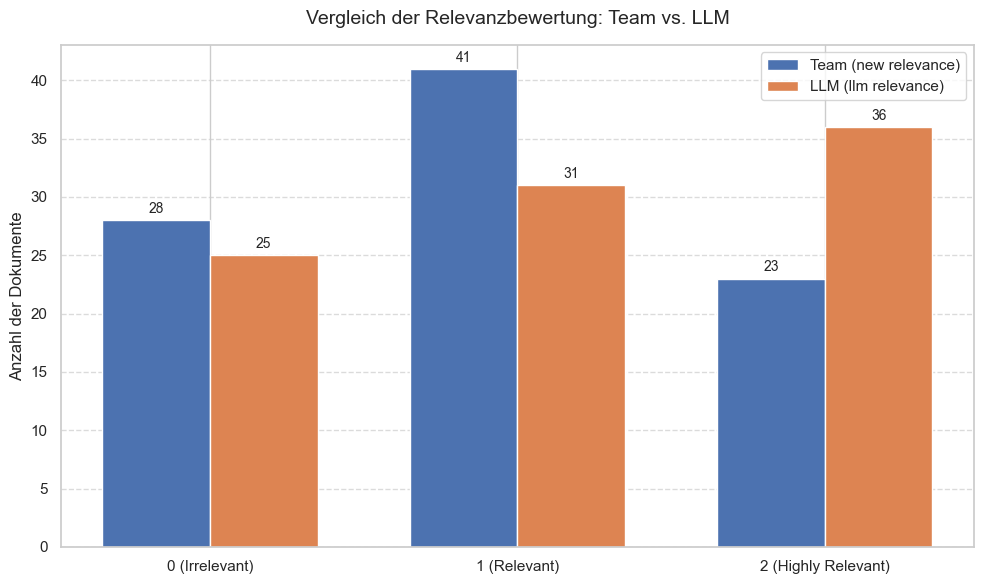

In [4]:
import numpy as np

# Häufigkeiten für beide Spalten zählen (reindex sorgt dafür, dass 0/1/2 immer alle auftauchen)
human_counts = df["new relevance"].value_counts().reindex([0, 1, 2], fill_value=0)
llm_counts = df["llm relevance"].value_counts().reindex([0, 1, 2], fill_value=0)

labels = ["0 (Irrelevant)", "1 (Relevant)", "2 (Highly Relevant)"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Zwei Balken nebeneinander: einer fürs Team, einer fürs LLM
rects1 = ax.bar(x - width / 2, human_counts, width, label="Team (new relevance)", color="#4C72B0")
rects2 = ax.bar(x + width / 2, llm_counts, width, label="LLM (llm relevance)", color="#DD8452")

ax.set_ylabel("Anzahl der Dokumente", fontsize=12)
ax.set_title("Vergleich der Relevanzbewertung: Team vs. LLM", fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.7)


def autolabel(rects):
    # Schreibt die genaue Zahl über jeden Balken
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
        )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


### 1.5 Extremfälle: Wo widersprechen sich Team und LLM total?

Jetzt suchen wir die Fälle, in denen Team und LLM sich komplett uneinig sind: einmal sagt das Team "total relevant" (2) und das LLM "komplett irrelevant" (0), und umgekehrt.

In [5]:
# Fall A: Team sagt Highly Relevant (2), LLM sagt Irrelevant (0) -> LLM hat es übersehen
fall_a = (df["new relevance"] == 2) & (df["llm relevance"] == 0)

# Fall B: Team sagt Irrelevant (0), LLM sagt Highly Relevant (2) -> LLM liegt komplett daneben
fall_b = (df["new relevance"] == 0) & (df["llm relevance"] == 2)

# Beide Fälle zusammen (| = ODER)
ausreisser_df = df[fall_a | fall_b].copy()

# Neue Spalte, damit man sofort sieht, um welchen Fall es sich handelt
ausreisser_df["Art des Widerspruchs"] = ausreisser_df.apply(
    lambda row: (
        "Team=2 / LLM=0 (Übersehen von LLM)"
        if row["new relevance"] == 2
        else "Team=0 / LLM=2 (Halluzination/Falsch positiv)"
    ),
    axis=1,
)

print(f"Gesamtanzahl gefundener Extremfälle: {len(ausreisser_df)}")
print(ausreisser_df["Art des Widerspruchs"].value_counts())

# Vorschau: ID, Bewertungen und die englischen Texte anzeigen
vorschau_spalten = [
    "qid",
    "new relevance",
    "llm relevance",
    "Art des Widerspruchs",
    "title - English",
    "abstract - English",
]
print("\n--- Erste 5 Extremfälle in der Vorschau ---")
display(ausreisser_df[vorschau_spalten].head())

# Als eigene CSV speichern, damit wir das im Team-Meeting besprechen können
ausreisser_df.to_csv("krasse_widersprueche.csv", sep=";", index=False)
print("\n-> Die Datei 'krasse_widersprueche.csv' wurde erfolgreich gespeichert!")


Gesamtanzahl gefundener Extremfälle: 5
Art des Widerspruchs
Team=0 / LLM=2 (Halluzination/Falsch positiv)    4
Team=2 / LLM=0 (Übersehen von LLM)               1
Name: count, dtype: int64

--- Erste 5 Extremfälle in der Vorschau ---


,qid,new relevance,llm relevance,Art des Widerspruchs,title - English,abstract - English
37,253235b2573e803d3d7cb91bbe626407,0,2,Team=0 / LLM=2 (Halluzination/Falsch positiv),Cultural Heritage Digitization in Indonesia: A...,"New technologies, such as digital photography,..."
38,253235b2573e803d3d7cb91bbe626407,0,2,Team=0 / LLM=2 (Halluzination/Falsch positiv),Cultural Heritage Digitization in Indonesia: A...,"New technologies, such as digital photography,..."
48,6513b320bfbcd0ed11d192b17f985131,0,2,Team=0 / LLM=2 (Halluzination/Falsch positiv),Emotional Intelligence and Academic Achievemen...,The present work is oriented to Emotional Inte...
56,70a7a4c11f729b8ced811befa82aa2b7,0,2,Team=0 / LLM=2 (Halluzination/Falsch positiv),Effects of a physical exercise program on phys...,This doctoral thesis aimed to contribute to th...
61,781ce9d684cf75f39303e94af5013c41,2,0,Team=2 / LLM=0 (Übersehen von LLM),Detecting Phishing Websites Using Machine Lear...,Phishing is a fraudulent technique that involv...



-> Die Datei 'krasse_widersprueche.csv' wurde erfolgreich gespeichert!


## Teil 2: Die 22 "English top" Dokumente im Detail

Ab hier geht es nur noch um die Untergruppe der 22 Dokumente, bei denen die englische Übersetzung **oben** (`top`) im Text stand

### 2.1 Nahaufnahme: Die 22 'English top' Dokumente

Erstmal identifizieren wir diese Dokumente und schauen sie uns mit Original-Titel und Abstract genauer an.

In [12]:
df = pd.read_csv("alle_human_und_llm_relabel.csv", sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# Nur Dokumente mit "top" behalten
# .str.strip() und .str.lower() fangen Tippfehler wie "Top " oder "TOP" ab
top_english_df = df[
    df["English where (top - bottom)"].str.strip().str.lower() == "top"
].copy()

print(f"Anzahl gefundener Dokumente mit 'top': {len(top_english_df)}")

# Die Spalten, die für die Analyse wichtig sind
analyse_spalten = [
    "qid",
    "language",
    "new relevance",
    "llm relevance",
    "title",
    "abstract",
]

# Nur die Spalten nehmen, die es in der CSV auch wirklich gibt
existierende_spalten = [col for col in analyse_spalten if col in df.columns]

print("\n--- Analyse der 'English top' Dokumente ---")
display(top_english_df[existierende_spalten])

# Extra als CSV speichern, damit man es in Excel neben die anderen Daten legen kann
top_english_df[existierende_spalten].to_csv("english_top_analyse.csv", sep=";", index=False)
print("\n-> Datei 'english_top_analyse.csv' wurde für euer Team-Meeting gespeichert!")


Anzahl gefundener Dokumente mit 'top': 22

--- Analyse der 'English top' Dokumente ---


,qid,language,new relevance,llm relevance,title,abstract
3,d6e9712bf4d78dc25582d46273456358,French,0,0,Les fake news comme brèche spatio-temporelle d...,"International audienceFor more than a century,..."
29,e9e12c23dcae83b144aecbcdf7183159,Finish,1,1,Concurrent image capture in a Raspberry Pi net...,Abstract. 3D scanners are used to create digit...
30,10c7ef19d812f4c1bacecc0ee54d30a8,Indonesisch,1,1,Upaya Peningkatan Pengetahuan Remaja dalam Det...,Breast cancer (carcinoma mammae) or in English...
33,253235b2573e803d3d7cb91bbe626407,Portugisisch,1,2,PRESERVAÇÃO DO PATRIMÓNIO CULTURAL COMO ESTRAT...,"In the city of Pemba, cultural heritage repres..."
34,253235b2573e803d3d7cb91bbe626407,Spanisch,1,2,Protegiendo la herencia cultural Chimbotana: d...,The revaluation of cultural heritage has been ...
40,32b77e26bf1e161271a79b443af3b421,Spanisch,1,1,Problemática institucional en la gestión de la...,The main objective of this thesis is to unders...
50,6513b320bfbcd0ed11d192b17f985131,Spanisch,1,2,Inteligencia emocional y desempeño académico e...,The research aimed to determine the relationsh...
51,6513b320bfbcd0ed11d192b17f985131,Spanisch,1,1,REALIDADES TEÓRICAS SOBRE LA INTELIGENCIA EMOC...,Theoretical insights into the development of e...
54,6d1f50ca1928f230f5e90b7573fedc85,Spanisch,1,2,La relación entre el rendimiento universitario...,Sleep deprivation is the condition of insuffic...
56,70a7a4c11f729b8ced811befa82aa2b7,Portugisisch,0,2,Effects of a physical exercise program on phys...,Tese de Doutoramento em Ciências do Desporto a...



-> Datei 'english_top_analyse.csv' wurde für euer Team-Meeting gespeichert!


### 2.2 Die 22 'English top' Dokumente: Team vs. LLM

Wie hat unser Team und die LLM diese 22 Dokumente bewertet?

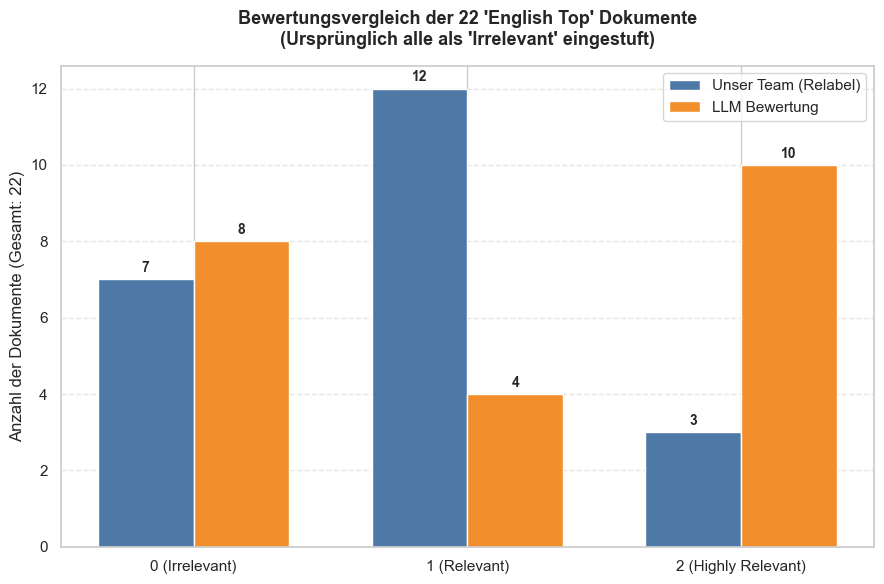

In [14]:
df = pd.read_csv("alle_human_und_llm_relabel.csv", sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

top_english_df = df[
    df["English where (top - bottom)"].str.strip().str.lower() == "top"
].copy()

team_counts = top_english_df["new relevance"].value_counts().reindex([0, 1, 2], fill_value=0)
llm_counts = top_english_df["llm relevance"].value_counts().reindex([0, 1, 2], fill_value=0)

labels = ["0 (Irrelevant)", "1 (Relevant)", "2 (Highly Relevant)"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

rects1 = ax.bar(x - width / 2, team_counts, width, label="Unser Team (Relabel)", color="#4E79A7")
rects2 = ax.bar(x + width / 2, llm_counts, width, label="LLM Bewertung", color="#F28E2B")

ax.set_ylabel("Anzahl der Dokumente (Gesamt: 22)", fontsize=12)
ax.set_title(
    "Bewertungsvergleich der 22 'English Top' Dokumente\n(Ursprünglich alle als 'Irrelevant' eingestuft)",
    fontsize=13,
    pad=15,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)


def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{int(height)}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )


add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()


## Teil 3: Erweiterte Analyse mit der neuen CSV

Ab hier arbeite ich mit `new_human_llm_relabel.csv`. Das ist eine aktualisierte Version des Datensatzes.

**Wichtig:** Ich habe dieser CSV manuell eine neue Spalte hinzugefügt: **`original title english (yes/no)`**

Diese Spalte sagt aus, ob der **Original-Titel** des Dokuments schon auf Englisch war (`yes`) oder nicht (`no`). Das ist etwas anderes als die Spalte `has english partial (yes/no)`, die nur sagt, ob *irgendwo* im Abstract ein englischer Teil vorkommt. Mit der neuen Spalte kann ich also gezielt die Fälle finden, in denen der Titel fremdsprachig war, aber trotzdem ein Stück Englisch im Abstract steckt.

### 3.1 Verteilung der neuen Spalte 'original title english'

Hier einfach die Häufigkeiten der neuen Spalte, die ich hinzugefügt habe: wie viele Dokumente hatten von Anfang an einen englischen Titel und wie viele nicht?

In [17]:
df = pd.read_csv("new_human_llm_relabel.csv", sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# Das ist die Spalte, die ich selbst manuell hinzugefügt habe
print(df["origianl title english (yes/no)"].value_counts())

origianl title english (yes/no)
no     65
yes    27
Name: count, dtype: int64


### 3.2 Dokumente finden: Titel nicht Englisch, aber Abstract enthält Englisch

In [15]:
dateiname = "new_human_llm_relabel.csv"
df = pd.read_csv(dateiname, sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# Spaltennamen automatisch finden, falls sich mal ein Tippfehler einschleicht
# (z.B. "origianl" statt "original")
title_col = [c for c in df.columns if "title english" in c.lower()][0]
partial_col = [c for c in df.columns if "has english partial" in c.lower()][0]

print(f"Gefundene Titel-Spalte: '{title_col}'")
print(f"Gefundene Partial-Spalte: '{partial_col}'\n")

# Bedingung: Titel war NICHT Englisch ('no'), aber im Abstract steckt Englisch ('yes')
bedingung = (df[title_col].str.strip().str.lower() == "no") & (
    df[partial_col].str.strip().str.lower() == "yes"
)
ergebnis_df = df[bedingung].copy()

print(f"Ergebnis: Es gibt insgesamt {len(ergebnis_df)} Dokumente, bei denen der Originaltitel fremdsprachig ist, aber das Abstract Englisch enthält.")

vorschau_spalten = [
    "qid",
    "language",
    "new relevance",
    "llm relevance",
    "title",
    "abstract",
]
existierende_spalten = [c for c in vorschau_spalten if c in df.columns]

if len(ergebnis_df) > 0:
    print("\n--- Vorschau der ersten 5 Dokumente ---")
    display(ergebnis_df[existierende_spalten].head(5))

    ergebnis_df.to_csv("titel_fremd_abstract_englisch.csv", sep=";", index=False)
    print("\n-> Die Treffer wurden erfolgreich in 'titel_fremd_abstract_englisch.csv' gespeichert!")
else:
    print("\nKeine Dokumente gefunden, die exakt auf diese Kombination zutreffen.")


Gefundene Titel-Spalte: 'origianl title english (yes/no)'
Gefundene Partial-Spalte: 'has english partial (yes / no)'

Ergebnis: Es gibt insgesamt 36 Dokumente, bei denen der Originaltitel fremdsprachig ist, aber das Abstract Englisch enthält.

--- Vorschau der ersten 5 Dokumente ---


,qid,language,new relevance,llm relevance,title,abstract
3,d6e9712bf4d78dc25582d46273456358,French,0,0,Les fake news comme brèche spatio-temporelle d...,"International audienceFor more than a century,..."
4,d6e9712bf4d78dc25582d46273456358,Italian,0,0,Notizie che violano le regole del giornalismo:...,Questa tesi ridefinisce il concetto filosofico...
9,d7121387aa077f9d346a6b5a0378e5c6,Portuguese,2,2,Procrastinação acadêmica e percepção da qualid...,"Procrastination, defined as the tendency to po..."
10,d7121387aa077f9d346a6b5a0378e5c6,Spanish,2,1,Procrastinación en estudiantes universitarios ...,Introduction: Procrastination has become an in...
11,d7121387aa077f9d346a6b5a0378e5c6,Indonesian /Arabic,1,2,Pengaruh digital burnout terhadap prokrastinas...,INDONESIA\n\n\n\nProkrastinasi akademik merupa...



-> Die Treffer wurden erfolgreich in 'titel_fremd_abstract_englisch.csv' gespeichert!


### 3.3 Wo genau im Abstract taucht der englische Teil auf?

Für die gleichen Dokumente wie eben (fremder Titel, aber Englisch im Abstract) schauen wir uns an, ob dieser englische Teil oben, unten oder an beiden Stellen steht.

In [16]:
dateiname = "new_human_llm_relabel.csv"
df = pd.read_csv(dateiname, sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

title_col = [c for c in df.columns if "title english" in c.lower()][0]
partial_col = [c for c in df.columns if "has english partial" in c.lower()][0]
where_col = [c for c in df.columns if "english where" in c.lower()][0]

bedingung = (df[title_col].str.strip().str.lower() == "no") & (
    df[partial_col].str.strip().str.lower() == "yes"
)
fremd_titel_df = df[bedingung].copy()

# Werte vereinheitlichen, damit Tippfehler/Groß-Kleinschreibung nicht stören
fremd_titel_df[where_col] = fremd_titel_df[where_col].str.strip().str.lower()

positionen = fremd_titel_df[where_col].value_counts(dropna=False)

print(f"Gesamtanzahl (Fremder Titel + Englisches Abstract): {len(fremd_titel_df)} Dokumente\n")
print("--- Wo befand sich der englische Teil im Abstract? ---")

for pos, count in positionen.items():
    # Schönere Beschriftung für die Ausgabe bauen
    if pd.isna(pos) or pos == "":
        label = "Nicht angegeben (leer)"
    elif "top" in pos and "bottom" in pos:
        label = "Sowohl oben als auch unten (komplett)"
    elif "top" in pos:
        label = "Oben (Top)"
    elif "bottom" in pos:
        label = "Unten (Bottom)"
    else:
        label = str(pos).capitalize()

    prozent = (count / len(fremd_titel_df)) * 100
    print(f"* {label}: {count} Dokumente ({prozent:.1f}%)")


Gesamtanzahl (Fremder Titel + Englisches Abstract): 36 Dokumente

--- Wo befand sich der englische Teil im Abstract? ---
* Unten (Bottom): 20 Dokumente (55.6%)
* Oben (Top): 16 Dokumente (44.4%)
